# 06 — Outliers: Detección y Tratamiento
**No todos los outliers son errores — algunos son la señal más importante.**

## Tipos de outliers
- **Univariados**: valores extremos en una sola variable (precio = $50,000 en dataset de ropa)
- **Multivariados**: combinación inusual de valores normales individualmente (edad=25, ingreso=$1M)
- **Contextuales**: normal en un contexto, anormal en otro (temperatura=40°C en invierno)

## Métodos de detección

| Método | Tipo | Supuesto | Cuándo |
|---|---|---|---|
| **Z-Score** | Univariado | Normalidad | Distribuciones simétricas |
| **IQR (Tukey)** | Univariado | Ninguno | Distribuciones sesgadas |
| **Isolation Forest** | Multivariado | Ninguno | Datasets de alta dimensión |
| **LOF** | Multivariado | Densidad local | Clusters de densidad variable |
| **DBSCAN** | Multivariado | Densidad | También hace clustering |

## IQR (Tukey fences)
$$\text{Lower} = Q1 - k \cdot IQR \quad \text{Upper} = Q3 + k \cdot IQR$$
donde $k=1.5$ para outliers leves, $k=3$ para extremos.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
})

rng = np.random.default_rng(42)
n   = 3000

categories = rng.choice(['Electronics','Clothing','Home','Sports','Books','Beauty'], n, p=[0.25,0.22,0.18,0.15,0.12,0.08])
price      = np.where(categories=='Electronics', rng.lognormal(4.5,0.8,n),
             np.where(categories=='Clothing',    rng.lognormal(3.5,0.6,n),
                                                 rng.lognormal(3.2,0.7,n))).round(2)
qty        = rng.integers(1, 8, n)
discount   = np.where(rng.uniform(0,1,n)<0.3, rng.uniform(0.05,0.40,n), 0.0).round(2)
revenue    = (price * qty * (1 - discount)).round(2)

# Inyectar outliers controlados
out_idx = rng.choice(n, size=30, replace=False)
revenue_out = revenue.copy()
revenue_out[out_idx[:15]] = rng.uniform(5000, 15000, 15)   # outliers altos
revenue_out[out_idx[15:]] = rng.uniform(-500, -10, 15)     # outliers negativos (errores)

df = pd.DataFrame({
    'category': categories, 'price': price,
    'quantity': qty, 'discount': discount, 'revenue': revenue_out,
})
print(f'Dataset: {df.shape} | Revenue min: ${df.revenue.min():.0f} | max: ${df.revenue.max():.0f}')

Dataset: (3000, 5) | Revenue min: $-495 | max: $14028


## 1 — Detección univariada: Z-Score e IQR

Z-Score (|z|>3):    24 outliers (0.80%)
IQR (k=1.5):       297 outliers (9.90%)
Outliers reales:  30 inyectados


/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_16723/2124828927.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df['revenue'], vert=True, patch_artist=True,


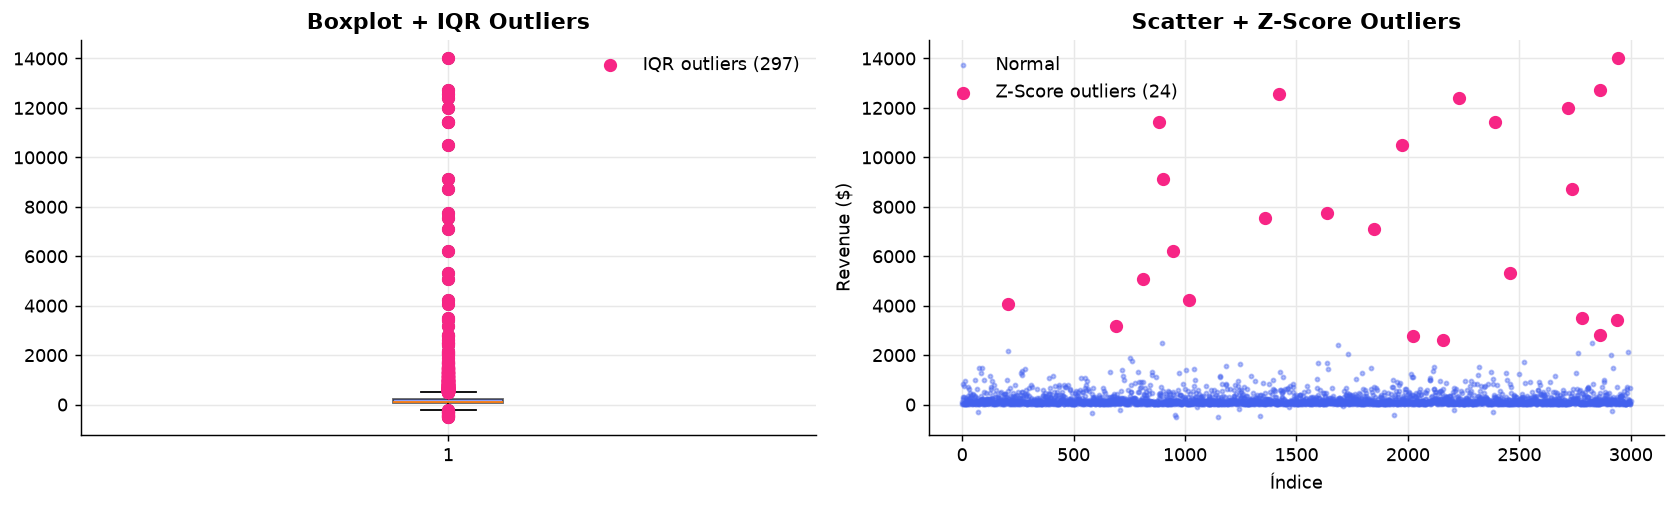

In [2]:
def detect_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    z = np.abs(stats.zscore(series.dropna()))
    out = pd.Series(False, index=series.index)
    out.loc[series.dropna().index] = z > threshold
    return out

def detect_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

out_z   = detect_zscore(df['revenue'], threshold=3.0)
out_iqr = detect_iqr(df['revenue'], k=1.5)

print(f'Z-Score (|z|>3):  {out_z.sum():>4} outliers ({out_z.mean():.2%})')
print(f'IQR (k=1.5):      {out_iqr.sum():>4} outliers ({out_iqr.mean():.2%})')
print(f'Outliers reales:  {30} inyectados')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Box plot con outliers marcados
axes[0].boxplot(df['revenue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4361ee', alpha=0.6))
axes[0].scatter([1]*out_iqr.sum(), df.loc[out_iqr, 'revenue'],
                color='#f72585', s=40, zorder=5, label=f'IQR outliers ({out_iqr.sum()})')
axes[0].set_title('Boxplot + IQR Outliers')
axes[0].legend()

# Scatter con Z-Score
axes[1].scatter(range(len(df)), df['revenue'], s=5, color='#4361ee', alpha=0.4, label='Normal')
axes[1].scatter(np.where(out_z)[0], df.loc[out_z, 'revenue'],
                s=40, color='#f72585', zorder=5, label=f'Z-Score outliers ({out_z.sum()})')
axes[1].set_xlabel('Índice'); axes[1].set_ylabel('Revenue ($)')
axes[1].set_title('Scatter + Z-Score Outliers')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2 — Detección multivariada: Isolation Forest y LOF

Isolation Forest: 60 outliers detectados
LOF:              60 outliers detectados
Ambos métodos:    11 en común


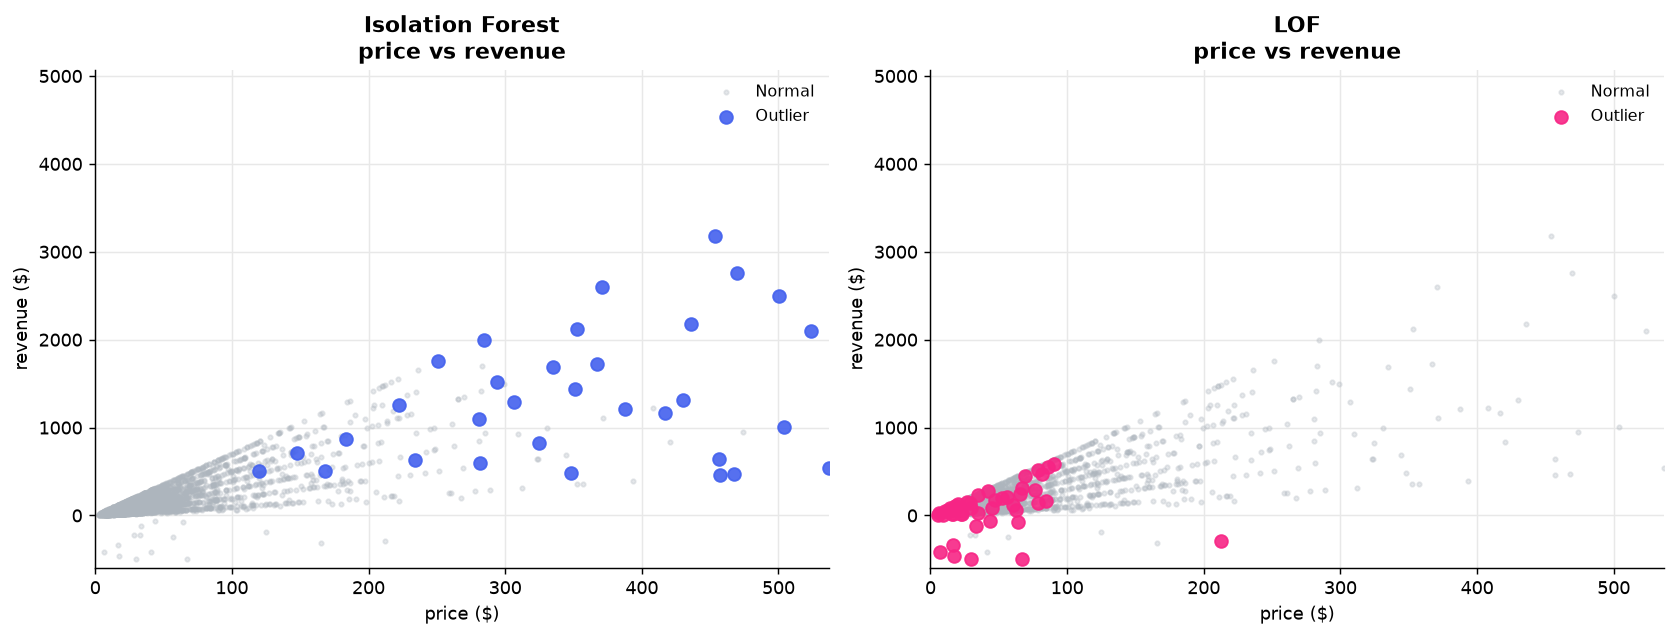

In [3]:
num_cols = ['price', 'quantity', 'discount', 'revenue']
X = df[num_cols].values
X_scaled = StandardScaler().fit_transform(X)

# Isolation Forest: contamination ≈ fracción esperada de outliers
iso = IsolationForest(contamination=0.02, random_state=42)
iso_labels = iso.fit_predict(X_scaled)  # -1 = outlier, 1 = normal
iso_scores = -iso.score_samples(X_scaled)  # más alto = más anómalo

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_labels = lof.fit_predict(X_scaled)  # -1 = outlier
lof_scores = -lof.negative_outlier_factor_

df['iso_outlier']   = iso_labels == -1
df['lof_outlier']   = lof_labels == -1
df['iso_score']     = iso_scores
df['lof_score']     = lof_scores

print(f'Isolation Forest: {df["iso_outlier"].sum()} outliers detectados')
print(f'LOF:              {df["lof_outlier"].sum()} outliers detectados')
print(f'Ambos métodos:    {(df["iso_outlier"] & df["lof_outlier"]).sum()} en común')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (col_score, col_flag, title, color) in zip(axes, [
    ('iso_score', 'iso_outlier', 'Isolation Forest\nprice vs revenue', '#4361ee'),
    ('lof_score', 'lof_outlier', 'LOF\nprice vs revenue', '#f72585'),
]):
    normal  = ~df[col_flag]
    outlier =  df[col_flag]
    ax.scatter(df.loc[normal,  'price'], df.loc[normal,  'revenue'], s=6, alpha=0.3, color='#adb5bd', label='Normal')
    ax.scatter(df.loc[outlier, 'price'], df.loc[outlier, 'revenue'], s=50, alpha=0.9, color=color,    label='Outlier', zorder=5)
    ax.set_xlabel('price ($)'); ax.set_ylabel('revenue ($)')
    ax.set_xlim(0, df['price'].quantile(0.995))
    ax.set_ylim(df['revenue'].min() - 100, df['revenue'].quantile(0.995))
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3 — Comparación de métodos: acuerdo entre detectores

In [4]:
df['iqr_outlier']    = detect_iqr(df['revenue'], k=1.5)
df['zscore_outlier'] = detect_zscore(df['revenue'], threshold=3.0)

methods = ['iqr_outlier', 'zscore_outlier', 'iso_outlier', 'lof_outlier']
df['n_methods_flagged'] = df[methods].sum(axis=1)

print('Consenso entre métodos:')
print(df['n_methods_flagged'].value_counts().sort_index().to_string())

# Los que 3+ métodos coinciden → outliers robustos
robust_outliers = df['n_methods_flagged'] >= 3
print(f'\nOutliers robustos (≥3 métodos): {robust_outliers.sum()} ({robust_outliers.mean():.2%})')
print(df[robust_outliers][['price','quantity','discount','revenue','n_methods_flagged']].head(10).to_string())

Consenso entre métodos:
n_methods_flagged
0    2661
1     272
2      42
3      15
4      10

Outliers robustos (≥3 métodos): 25 (0.83%)
        price  quantity  discount       revenue  n_methods_flagged
208   1017.81         4      0.00   4071.240000                  3
692    453.81         7      0.00   3176.670000                  3
811    845.36         6      0.00   5072.160000                  3
883     23.95         6      0.00  11422.969033                  4
901     42.09         1      0.00   9136.932457                  4
948     28.91         2      0.12   6209.693098                  4
1018   606.13         7      0.00   4242.910000                  3
1358    43.57         6      0.00   7538.844085                  3
1423    36.18         1      0.00  12546.519313                  4
1637    51.41         1      0.00   7761.922726                  4


## 4 — Tratamiento de outliers

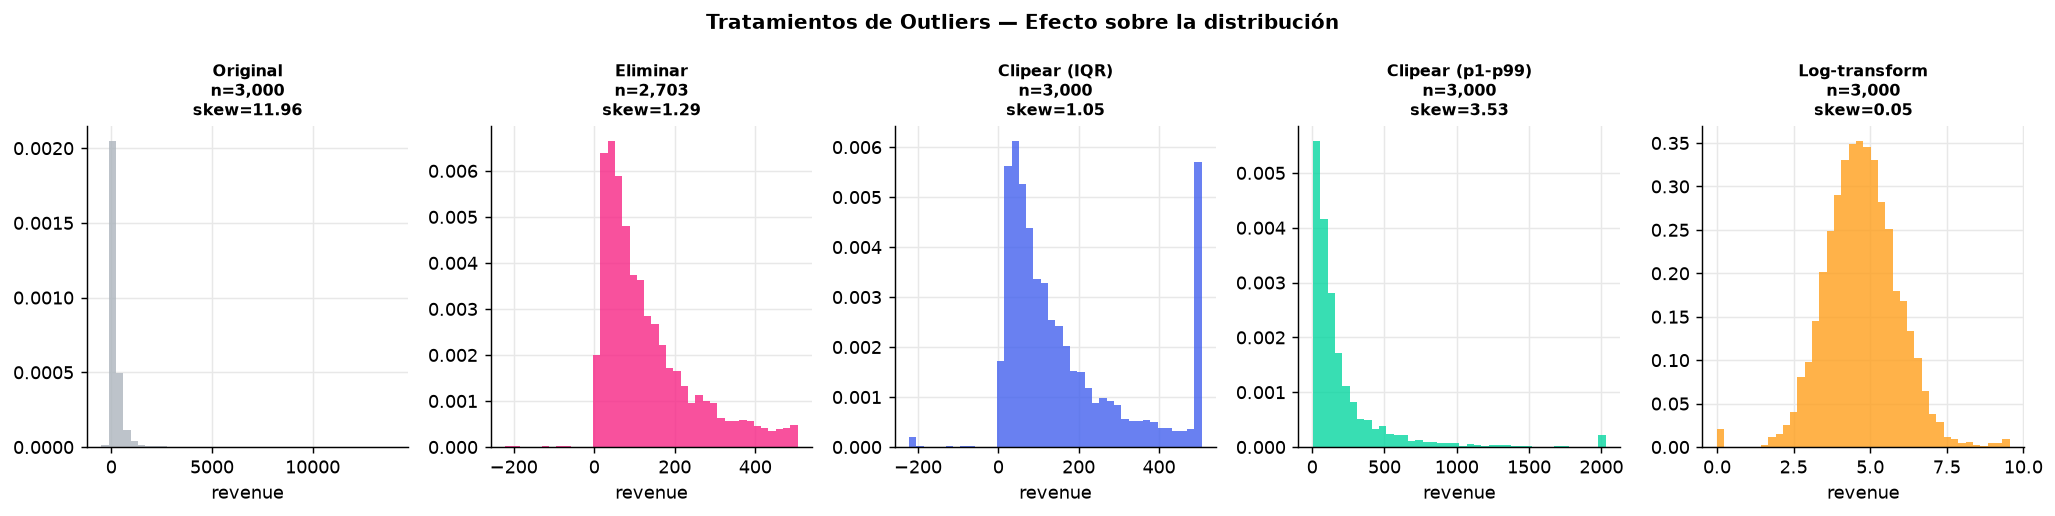

Guía de elección:
  Eliminar       → cuando son errores de datos confirmados
  Clipear IQR    → cuando quieras mantener todas las filas pero limitar influencia
  Clipear p1-p99 → más conservador, preserva más variabilidad real
  Log-transform  → cuando los outliers son parte de una distribución lognormal
  No hacer nada  → modelos robustos (árboles, GBT) — los outliers no los afectan tanto


In [5]:
rev = df['revenue']
q1, q3 = rev.quantile(0.25), rev.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

tratamientos = {
    'Original':        rev,
    'Eliminar':        rev[~detect_iqr(rev)],
    'Clipear (IQR)':   rev.clip(lower=lower, upper=upper),
    'Clipear (p1-p99)':rev.clip(lower=rev.quantile(0.01), upper=rev.quantile(0.99)),
    'Log-transform':   np.log1p(rev.clip(lower=0)),
}

fig, axes = plt.subplots(1, len(tratamientos), figsize=(16, 4))
colors = ['#adb5bd','#f72585','#4361ee','#06d6a0','#ff9f1c']

for ax, (name, data), color in zip(axes, tratamientos.items(), colors):
    ax.hist(data, bins=40, color=color, alpha=0.8, density=True)
    ax.set_title(f'{name}\nn={len(data):,}\nskew={data.skew():.2f}', fontsize=9)
    ax.set_xlabel('revenue')

plt.suptitle('Tratamientos de Outliers — Efecto sobre la distribución', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Guía de elección:')
print('  Eliminar       → cuando son errores de datos confirmados')
print('  Clipear IQR    → cuando quieras mantener todas las filas pero limitar influencia')
print('  Clipear p1-p99 → más conservador, preserva más variabilidad real')
print('  Log-transform  → cuando los outliers son parte de una distribución lognormal')
print('  No hacer nada  → modelos robustos (árboles, GBT) — los outliers no los afectan tanto')

## Resumen — Flujo de decisión

```
1. Detectar con IQR (rápido, no paramétrico)
2. Inspeccionar manualmente los casos flaggeados
   ¿Son errores de ingesta? → Eliminar o corregir
   ¿Son valores reales extremos? → Conservar, considerar clipear
   ¿Son la señal más importante? → Conservar, documentar
3. Para ML:
   - Modelos lineales / KNN → sensibles → clipear o log-transform
   - Árboles / GBT          → robustos → pueden usarse sin tratar
4. Validar con Isolation Forest (multivariado) para detectar
   combinaciones anómalas que el IQR univariado no ve
```

**Siguiente:** `07_eda_report.ipynb`